In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.stattools import acf, pacf

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

SEED_VALUE = 1
import random
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

import warnings 
warnings.filterwarnings('ignore')

2026-06-29 04:05:07.484923: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782705907.876657      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782705908.026774      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782705909.252843      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782705909.252887      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782705909.252890      23 computation_placer.cc:177] computation placer alr

# 1a) EDA & Data Split

In [2]:
df = pd.read_csv("/kaggle/input/datasets/visednorm/uas-dl/Dataset C/INTC.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-03-17,0.325521,0.330729,0.325521,0.325521,0.204750,10924800
1,1980-03-18,0.325521,0.328125,0.322917,0.322917,0.203112,17068800
2,1980-03-19,0.330729,0.335938,0.330729,0.330729,0.208026,18508800
3,1980-03-20,0.330729,0.334635,0.329427,0.329427,0.207207,11174400
4,1980-03-21,0.322917,0.322917,0.317708,0.317708,0.199836,12172800
...,...,...,...,...,...,...,...
10093,2020-03-26,51.740002,55.950001,51.660000,55.540001,55.540001,41459800
10094,2020-03-27,53.419998,54.639999,52.070000,52.369999,52.369999,31633500
10095,2020-03-30,52.990002,56.099998,52.830002,55.490002,55.490002,31628600
10096,2020-03-31,55.060001,55.799999,53.220001,54.119999,54.119999,48074700


In [3]:
df.shape

(10098, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10098 entries, 0 to 10097
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10098 non-null  object 
 1   Open       10098 non-null  float64
 2   High       10098 non-null  float64
 3   Low        10098 non-null  float64
 4   Close      10098 non-null  float64
 5   Adj Close  10098 non-null  float64
 6   Volume     10098 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 552.4+ KB


## Useless Columns

In [5]:
#only using Date and Close
df.drop(columns=['High', 'Open', 'Low', 'Adj Close', 'Volume'], inplace=True)
df.columns

Index(['Date', 'Close'], dtype='object')

## Duplicates

In [6]:
#checking dupes from Date
df['Date'].value_counts()

Date
1980-03-17    1
1980-03-18    1
1980-03-19    1
1980-03-20    1
1980-03-21    1
             ..
2020-03-26    1
2020-03-27    1
2020-03-30    1
2020-03-31    1
2020-04-01    1
Name: count, Length: 10098, dtype: int64

## Mismatch Data Types

In [7]:
#converting Date object to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10098 entries, 0 to 10097
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10098 non-null  datetime64[ns]
 1   Close   10098 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 157.9 KB


## Data Distribution

In [8]:
#checking descriptive statistics
df.describe()

,Date,Close
count,10098,10098.000000
mean,2000-03-15 15:28:29.090909056,17.771604
min,1980-03-17 00:00:00,0.216146
25%,1990-03-12 06:00:00,1.132812
50%,2000-03-07 12:00:00,19.255000
75%,2010-03-22 18:00:00,27.307499
max,2020-04-01 00:00:00,74.875000
std,NaN,16.108504


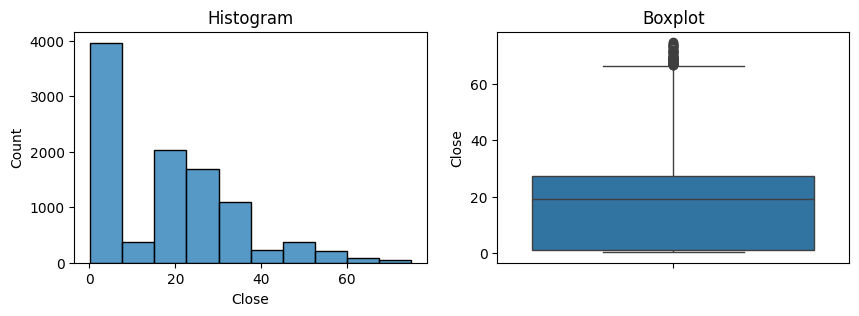

Skewness: 0.7230509194708613
Kurtosis: 0.036552458104122554


In [9]:
#checking Close distribution
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.histplot(df['Close'], bins=10)
plt.title('Histogram')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Close'])
plt.title('Boxplot')
plt.show()

print('Skewness:', df['Close'].skew())
print('Kurtosis:', df['Close'].kurt())

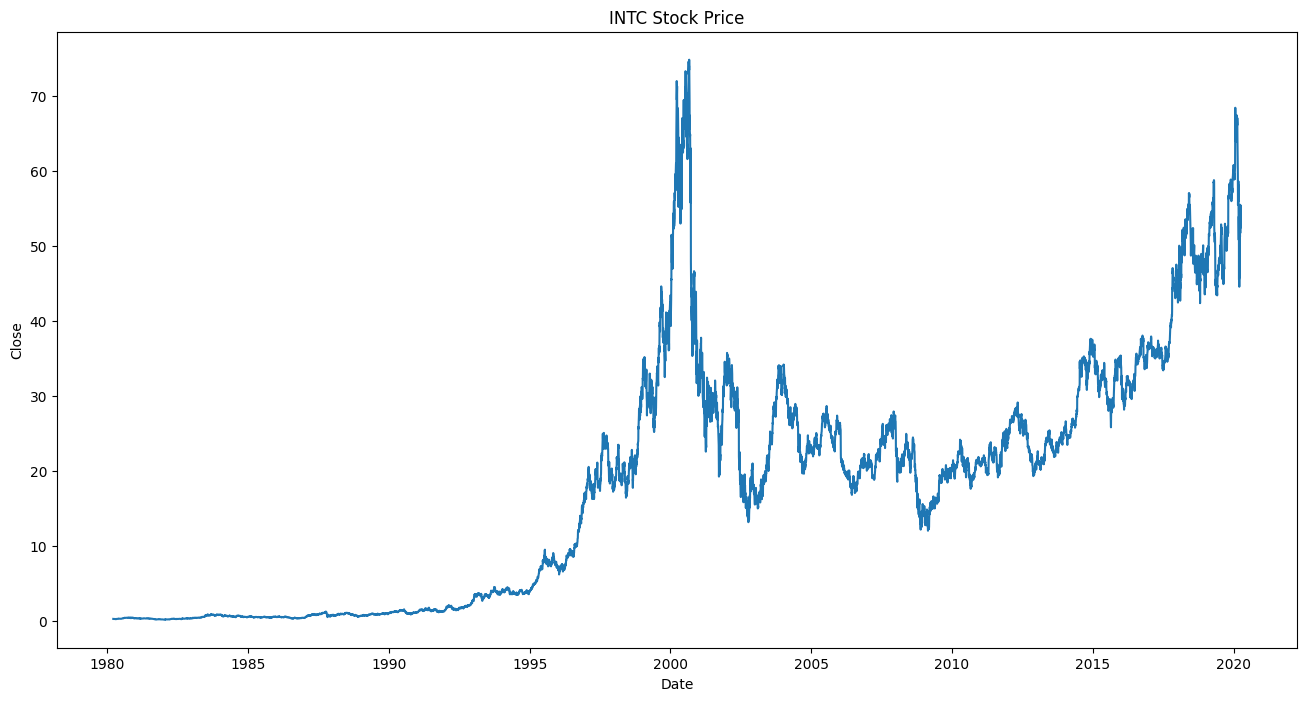

In [10]:
# plotting Close chart
plt.figure(figsize=(16,8))
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("INTC Stock Price")
plt.plot(df['Date'], df['Close'])
plt.show()

## Stationarity

In [11]:
def checkStationarity(df):
    #hitung rolling statistics
    rolmean = df.rolling(20).mean()
    rolstd = df.rolling(20).std()

    #plotting rolling statistics:
    original = plt.plot(df, color='black',label='Original')
    mean = plt.plot(rolmean, color='blue', label='Rolling Mean')
    std = plt.plot(rolstd, color='red', label = 'Rolling Std')
    
    plt.title('Rolling Mean and Standard Deviation Chart')
    plt.legend()
    plt.show()

    #cek Augmented Dickey-Fuller (ADF) test:
    print('== Dickey-Fuller Test ==')
    dftest = adfuller(df, autolag='AIC')
    
    dfoutput = pd.Series(dftest[0:2], index=['Test Statistic','p-value'])
    
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput, '\n')
    
    if dftest[1] <= 0.05:
        print("Data is stationary (p-value < 0.05)")
    else:
        print("Data is not stationary (p-value >= 0.05)")

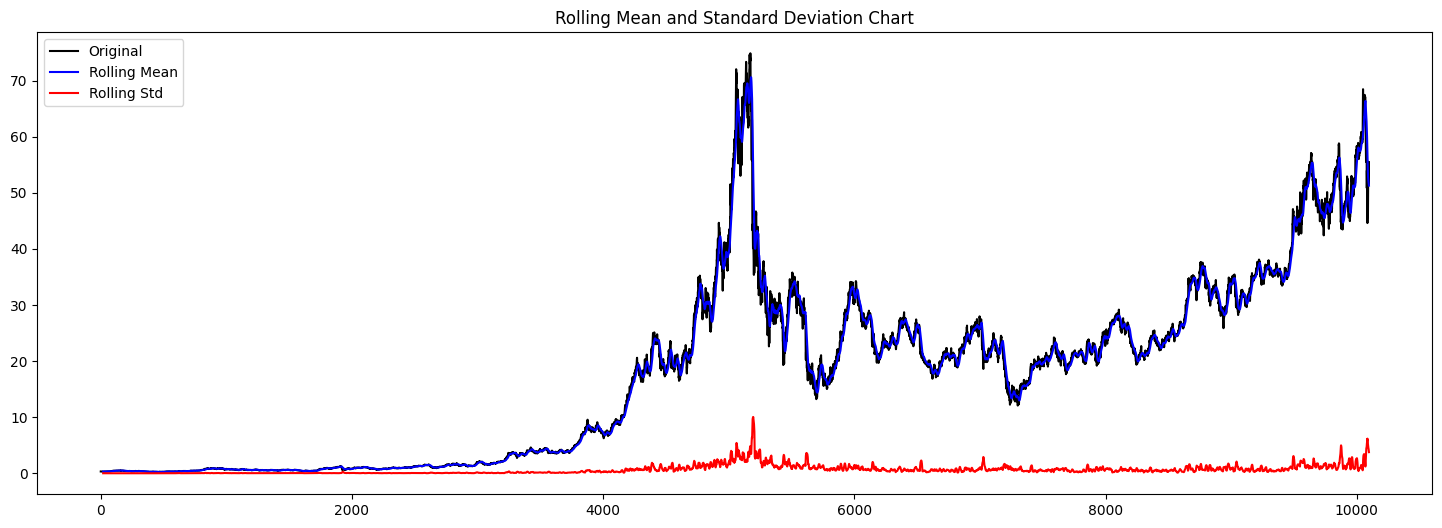

== Dickey-Fuller Test ==
Test Statistic         -1.148565
p-value                 0.695321
Critical Value (1%)    -3.431000
Critical Value (5%)    -2.861827
Critical Value (10%)   -2.566923
dtype: float64 

Data is not stationary (p-value >= 0.05)


In [12]:
plt.figure(figsize = (18,6))
checkStationarity(df['Close'])

Berdasarkan chart di atas, terlihat bahwa rolling mean terus-menerus meningkat seiring berjalannya waktu. Artinya, data time-series itu tidak stationary. Selain itu, hasil pengecekan ADF menunjukkan p-value 0.69 >= 0.05, berarti null hypothesis tidak bisa ditolak. Hal ini diperkuat lagi dengan test statistic -1.14 yang menunjukkan angka lebih dari crit value 5% -2.86, sehingga dengan 95% Confidence Interval, kita bisa yakin bahwa null hypothesis tidak boleh ditolak. Oleh karena itu, kita perlu melakukan transformasi data untuk membuat data menjadi stationary.

## Seasonality

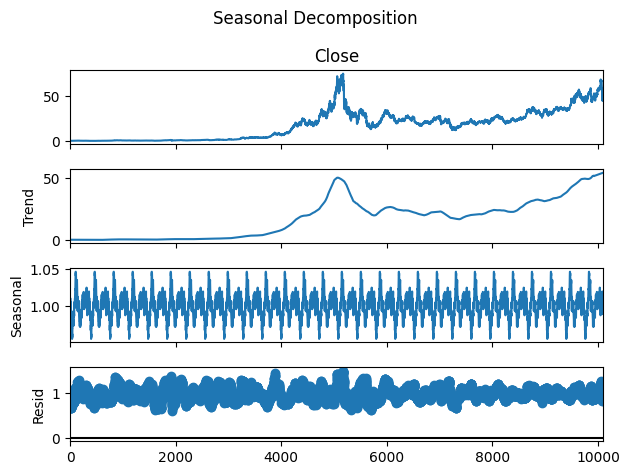

In [13]:
result = seasonal_decompose(
    df['Close'], 
    model='multiplicative', 
    extrapolate_trend='freq', 
    period=360
)
result.plot()

plt.suptitle('Seasonal Decomposition')
plt.tight_layout()
plt.show()

* Trend: Dalam jangka panjang, terlihat jelas bahwa Close price terus meningkat yang menunjukkan adanya trend ke atas.
* Seasonal: pola tiap kuartal (3 bulan) terlihat adanya ada siklus Close price cenderung turun sekitar 0.96 dan naik 1.06. Grafiknya juga konstan dan seragam dari awal sampai akhir karena penggunaan multiplicative.
* Residual: Lebar atau ketebalan band-nya sekarang relatif sama dan stabil.

Text(0.5, 1.0, 'Log Transformed Chart')

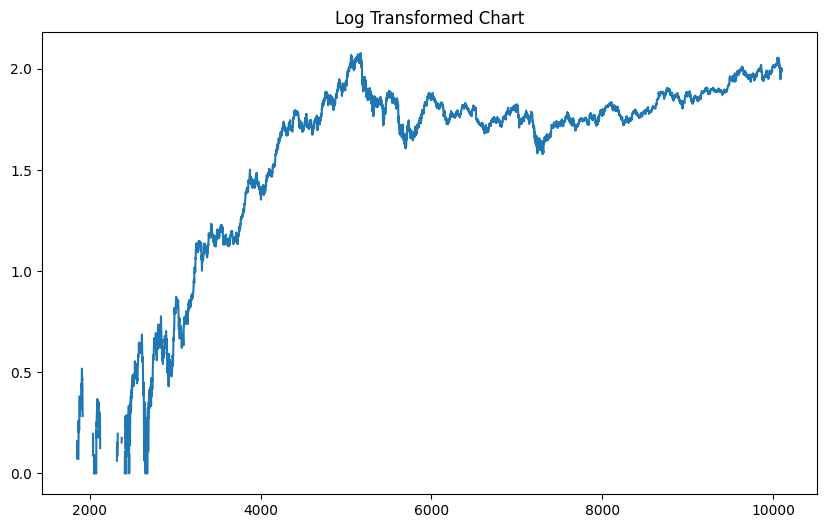

In [14]:
df_close_log = df['Close'].apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Log Transformed Chart')

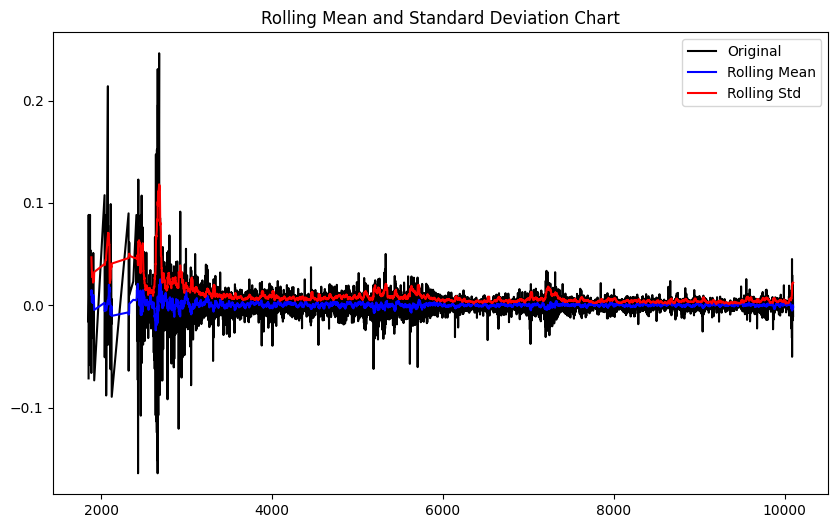

== Dickey-Fuller Test ==
Test Statistic         -1.592554e+01
p-value                 7.835141e-29
Critical Value (1%)    -3.431196e+00
Critical Value (5%)    -2.861914e+00
Critical Value (10%)   -2.566969e+00
dtype: float64 

Data is stationary (p-value < 0.05)


In [15]:
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
checkStationarity(df_close_shift)

Setelah melakukan log transformation shifting pada data awal, terlihat bahwa hasil tes ADF sekarang sudah menandakan bahwa data bersifat stationary (p-value 7.83e-29 < 0.05). Selain itu, angka Test Statistic -15.92 juga sekarang sudah jauh di bawah crit value 1% -3.43, sehingga dengan 99% CI bisa dikatakan bahwa data kita kini stationary.

## PACF

In [16]:
np.abs(pacf(df_close_shift,nlags=30))
print(np.where(np.abs(pacf(df['Close'],nlags=30))>0.05)[0])

[ 0  1  2  9 14]


## Windowing

In [17]:
def createWindow(sequence, days, feature):
    X, y = list(), list()
    for i in range(len(sequence)):
        horizon = i + days
        
        if horizon >= len(sequence):
            break
            
        seq_x, seq_y = sequence[i:horizon], sequence[horizon]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], feature))
    return X, y

In [18]:
window = 5
X, y = createWindow(df_close_shift.to_numpy(), window, 1)

X.shape, y.shape

((7766, 5, 1), (7766,))

## Train-Test Split

In [19]:
# train 90%, test 10%
split_idx = int(len(X) * 0.9)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

print("Total:", len(X))
print("X_train:", X_train.shape, "y_train:", y_train.shape, round(y_train.shape[0]/len(X)*100,2), '%')
print("X_test :", X_test.shape, "y_test :", y_test.shape,  round(y_test.shape[0]/len(X)*100,2), '%')

Total: 7766
X_train: (6989, 5, 1) y_train: (6989,) 89.99 %
X_test : (777, 5, 1) y_test : (777,) 10.01 %


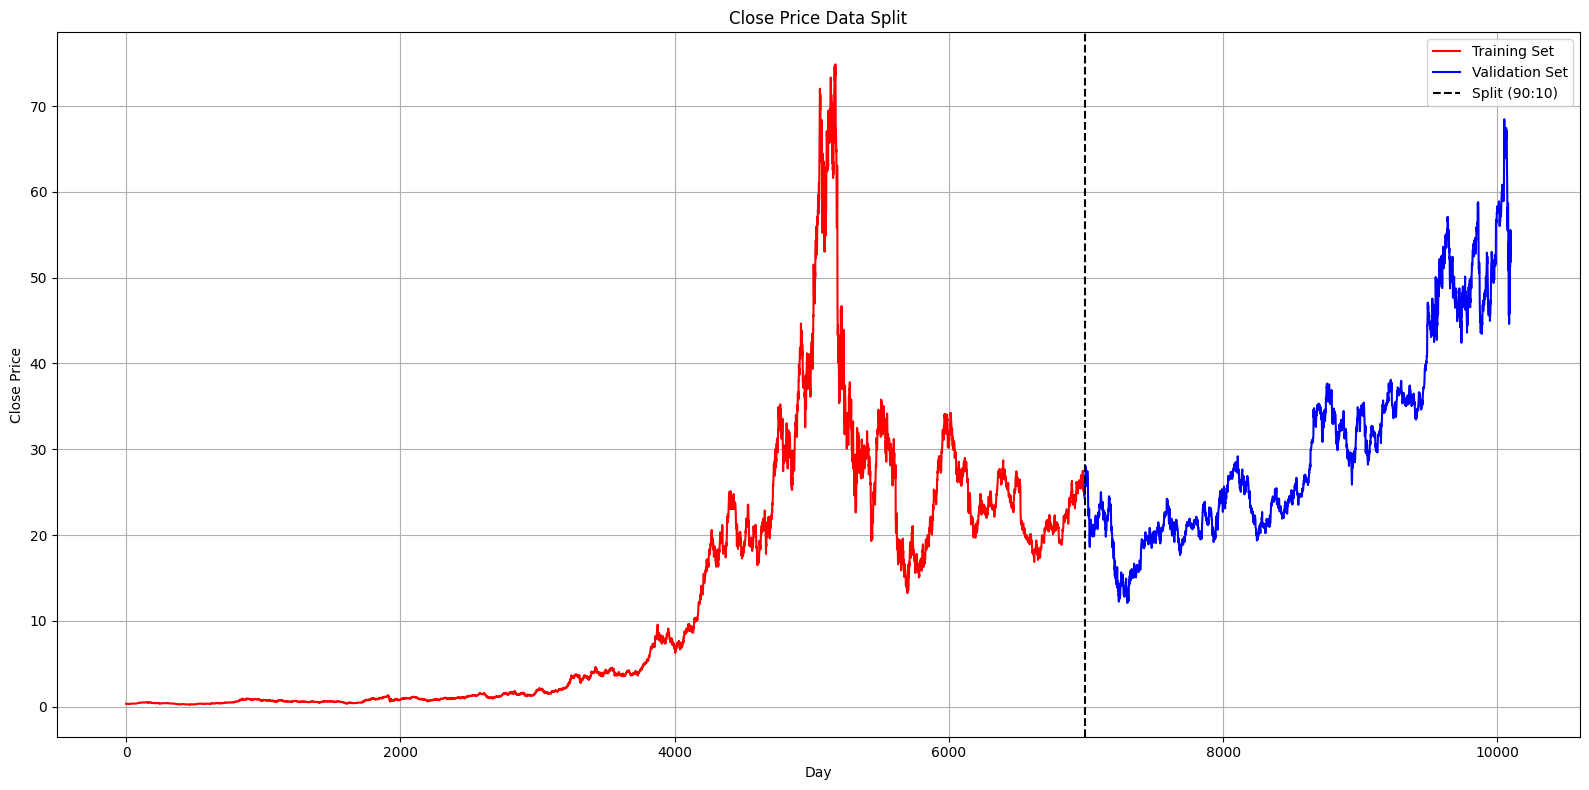

In [20]:
# visualisiasi train-test split
df_train = df[['Close']].iloc[:split_idx].values
df_valid = df[['Close']].iloc[split_idx:].values

plt.figure(figsize=(16, 8))

plt.plot(range(len(df_train)), df_train, label='Training Set', color='red')

start_idx = len(df_train)
end_idx = len(df_train) + len(df_valid)
plt.plot(range(start_idx, end_idx), df_valid, label='Validation Set', color='blue')

plt.axvline(x=split_idx, color='black', linestyle='--', label=f'Split (90:10)')

plt.title('Close Price Data Split')
plt.xlabel('Day')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 1b) Baseline Model

## Baseline LSTM

In [21]:
model = Sequential(name="Baseline_LSTM")

model.add(LSTM(
    units=50, 
    activation='relu', 
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Dense(units=1, name="Output"))

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='mse',
    metrics=['mae']
)
model.summary()

I0000 00:00:1782705931.856511      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782705931.859482      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20


I0000 00:00:1782705935.645444      74 service.cc:152] XLA service 0x7be338010920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782705935.645478      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782705935.645482      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782705936.123861      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


 55/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6996e-04 - mae: 0.0075

I0000 00:00:1782705937.287787      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


437/437 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.9750e-04 - mae: 0.0074 - val_loss: 3.2187e-05 - val_mae: 0.0036
Epoch 2/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9619e-04 - mae: 0.0073 - val_loss: 3.2153e-05 - val_mae: 0.0036
Epoch 3/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9567e-04 - mae: 0.0073 - val_loss: 3.2198e-05 - val_mae: 0.0036
Epoch 4/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9510e-04 - mae: 0.0073 - val_loss: 3.2827e-05 - val_mae: 0.0036
Epoch 5/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9434e-04 - mae: 0.0073 - val_loss: 3.2475e-05 - val_mae: 0.0036
Epoch 6/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9413e-04 - mae: 0.0073 - val_loss: 3.3308e-05 - val_mae: 0.0037
Epoch 7/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9399e-04 - mae: 0.0073 - val_loss: 3.2904e-05 - val_mae: 0.0036
Epoch 8/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9379e-04 - mae: 0.0073 - val_loss: 3.3632e-05 - val_mae: 0.0037
Epo

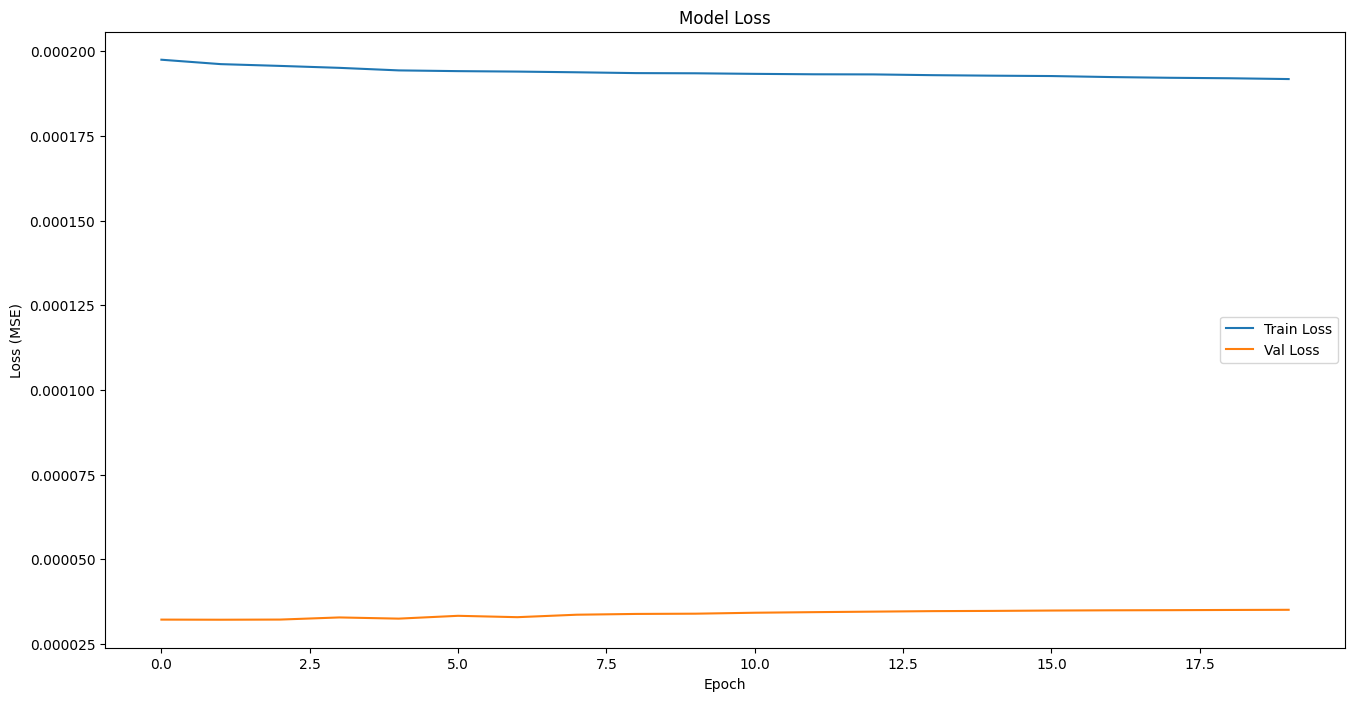

In [23]:
plt.figure(figsize=(16, 8))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Berdasarkan Loss plot di atas, terlihat bahwa line train-val loss dari Epoch awal hingga akhir seperti datar. Fenomena ini terjadi karena data yang ditransformasi dengan log mengubah skala variasi pada data. Akibatnya, rentang naik-turun loss selama training menjadi sulit diamati. Selain itu, karena performa loss sejak awal sudah sangat kecil, plot gagal menangkap perubahan kecil dari sisa penurunan loss tersebut.

In [24]:
print("Test Set Evaluation")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Test Set Evaluation
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5085e-05 - mae: 0.0039
Test MSE: 3.5084547562291846e-05
Test MAE: 0.003866214072331786


In [25]:
def inverseTransform(y_pred, y_test, df_original, df_transform):
    valid_dates = df_original.index[-len(y_pred):]

    pred_data = pd.DataFrame(index=valid_dates)
    pred_data['pred_raw'] = y_pred.flatten()
    pred_data['real_raw'] = y_test.flatten()

    # inverse diferensiasi
    shift_values = df_transform.shift().values[-len(y_pred):]
    pred_data['pred_log'] = pred_data['pred_raw'] + shift_values
    pred_data['real_log'] = pred_data['real_raw'] + shift_values

    # inverse sqrt to log
    pred_data['pred_sq'] = np.square(pred_data['pred_log'])
    pred_data['real_sq'] = np.square(pred_data['real_log'])

    # inverse log to real
    pred_data['pred'] = np.exp(pred_data['pred_sq'])
    pred_data['real'] = np.exp(pred_data['real_sq'])

    return pred_data[['real', 'pred']]

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


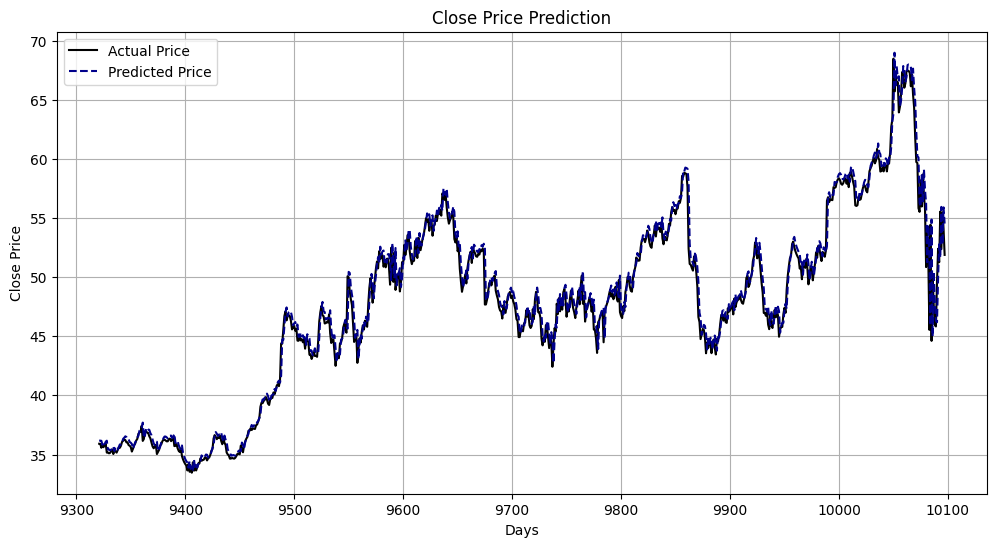

In [26]:
y_pred = model.predict(X_test)
df_result = inverseTransform(y_pred, y_test, df, df_close_tf)

plt.figure(figsize=(12, 6))
plt.grid()
plt.xlabel('Days')
plt.ylabel('Close Price')

plt.plot(df_result.index, df_result['real'], 'black', label='Actual Price')
plt.plot(df_result.index, df_result['pred'], 'darkblue', label='Predicted Price', linestyle='--')

plt.title('Close Price Prediction')
plt.legend()
plt.show()

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_true = df_result['real'].values
y_pred = df_result['pred'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

print("Performance Metrics")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.3f}%")

Performance Metrics
MAE  : 0.746
RMSE : 1.174
MAPE : 1.534%


# 1c) Modified Model

## Modified LSTM

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model2 = Sequential(name="LSTM_modif")

model2.add(LSTM(
    units=50, 
    activation='relu', 
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model2.add(Dropout(0.2)) # Tambah Dropout
model2.add(Dense(units=1, name="Output"))

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

model2.summary()

Model: "LSTM_modif"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Untuk bagian modifikasi model, tujuan utamanya adalah untuk generalisasi model karena model baseline sudah sangat bagus. Dilakukan perubahan arsitektur baseline dengan menambahkan satu layer dropout serta menerapkan fungsi callback early stopping. Modifikasi ini sengaja dirancang secara minim dan untuk membantu menekan validation loss.

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train, y_train,
    epochs=100,              
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 1.9449e-04 - mae: 0.0071 - val_loss: 3.2007e-05 - val_mae: 0.0035
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9450e-04 - mae: 0.0071 - val_loss: 3.1948e-05 - val_mae: 0.0035
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.9346e-04 - mae: 0.0071 - val_loss: 3.1960e-05 - val_mae: 0.0035
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9400e-04 - mae: 0.0071 - val_loss: 3.1873e-05 - val_mae: 0.0035
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9377e-04 - mae: 0.0071 - val_loss: 3.1855e-05 - val_mae: 0.0035
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.9325e-04 - mae: 0.0071 - val_loss: 3.1853e-05 - val_mae: 0.0035
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9336e-04 - mae: 0.0071 - val_loss: 3.1842e-05 - val_mae: 0.0035
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9281e-04 - mae: 0.0071 - val_loss: 3.1861e-05 -

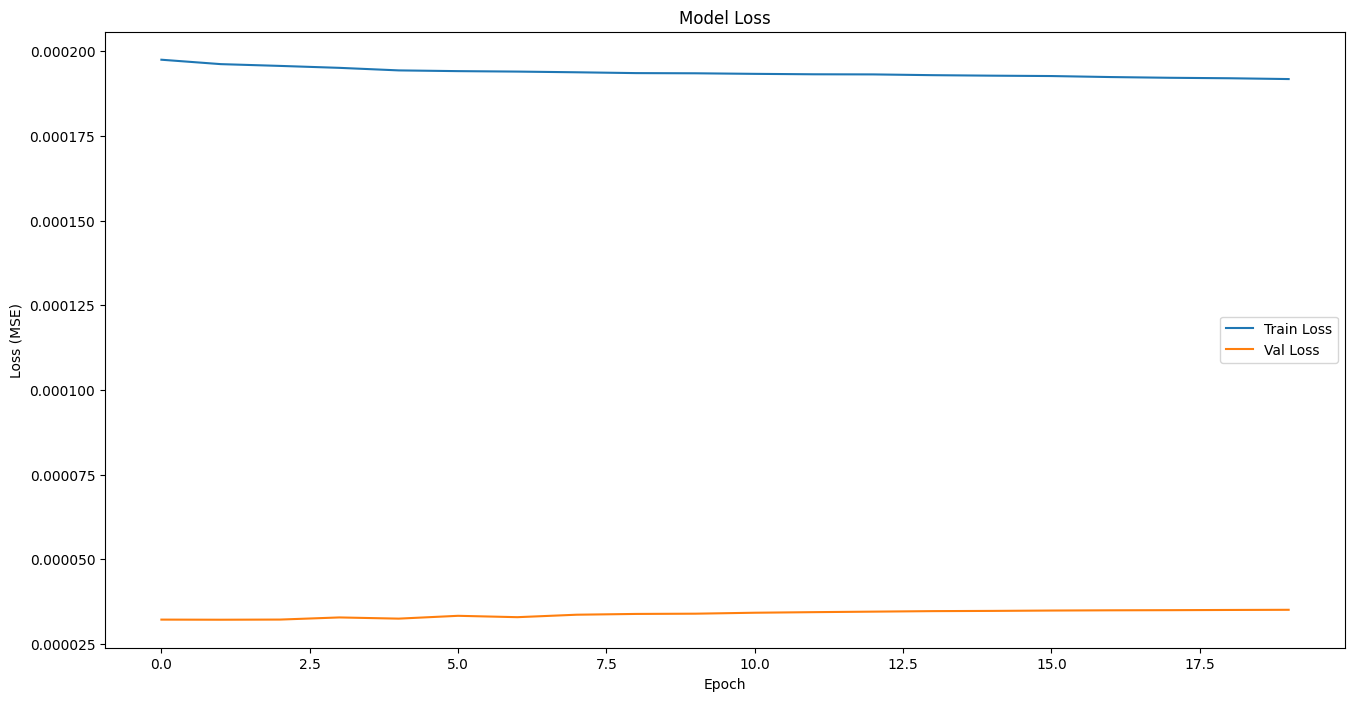

In [30]:
plt.figure(figsize=(16, 8))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Berdasarkan Loss plot di atas, terlihat bahwa line train-val loss dari Epoch awal hingga akhir seperti datar. Fenomena ini terjadi karena data yang ditransformasi dengan log mengubah skala variasi pada data. Akibatnya, rentang naik-turun loss selama training menjadi sulit diamati. Selain itu, karena performa loss sejak awal sudah sangat kecil, plot gagal menangkap perubahan kecil dari sisa penurunan loss tersebut. Secara khusus, bisa dilihat pada Epoch 10, mulai ada peningkatan val loss dengan train loss datar yang mengindikasikan tahap awal terjadinya overfitting. Namun, hal ini berhasil dicegah oleh EarlyStopping, meskipun dengan skala loss sekecil ini tidak terlalu berpengaruh pada model.

In [31]:
print("Test Set Evaluation")
results = model2.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Test Set Evaluation
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1762e-05 - mae: 0.0035
Test MSE: 3.176151221850887e-05
Test MAE: 0.0035323421470820904


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


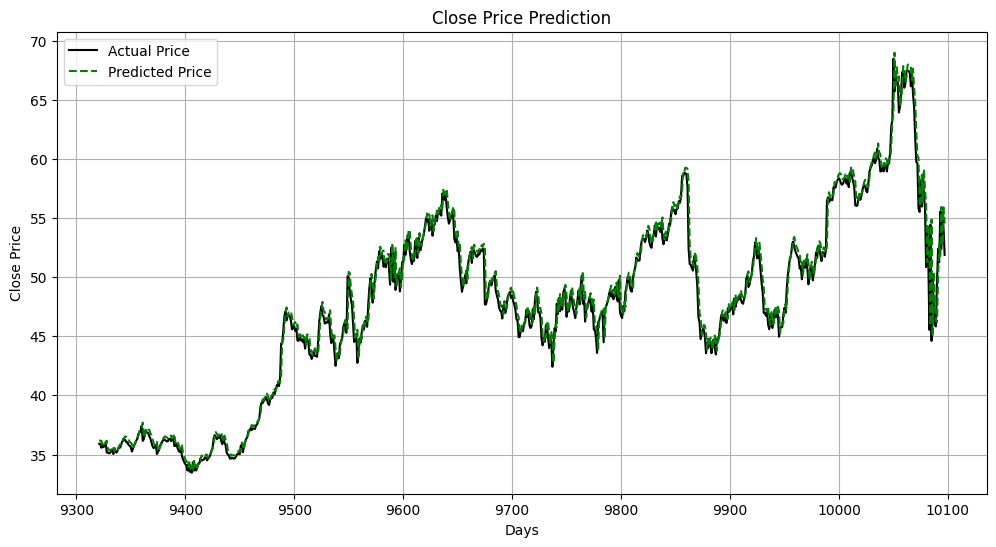

In [32]:
y_pred = model2.predict(X_test)
df_result2 = inverseTransform(y_pred, y_test, df, df_close_tf)

plt.figure(figsize=(12, 6))
plt.grid()
plt.xlabel('Days')
plt.ylabel('Close Price')

plt.plot(df_result2.index, df_result['real'], 'black', label='Actual Price')
plt.plot(df_result2.index, df_result['pred'], 'green', label='Predicted Price', linestyle='--')

plt.title('Close Price Prediction')
plt.legend()
plt.show()

# 1d) Evaluation

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_true = df_result['real'].values
y_pred = df_result['pred'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

print("Baseline Performance Metrics")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.3f}%")

Baseline Performance Metrics
MAE  : 0.746
RMSE : 1.174
MAPE : 1.534%


In [34]:
y_true2 = df_result2['real'].values
y_pred2 = df_result2['pred'].values

mae2 = mean_absolute_error(y_true, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_true, y_pred2))
mape2 = np.mean(np.abs((y_true - y_pred2) / np.where(y_true == 0, 1, y_true))) * 100

print("Modified Performance Metrics")
print(f"MAE  : {mae2:.3f}")
print(f"RMSE : {rmse2:.3f}")
print(f"MAPE : {mape2:.3f}%")

Modified Performance Metrics
MAE  : 0.681
RMSE : 1.117
MAPE : 1.394%


Membandingkan kedua model, terlihat bahwa model modified berhasil meningkat performanya di seluruh performance metrics dibandingkan dengan model baseline. MAE atau tingkat kesalahan rata-rata absolut model menurun secara signifikan dari 0.746 menjadi 0.681. Selain itu, penurunan kesalahan persentase rata-rata (MAPE) dari 1.534% menjadi 1.394%. Hal ini berarti penambahan Dropout dan adjustment pada Learning rate telah berhasil membuat prediksi model menjadi lebih presisi dan mendekati nilai rilnya.

Model modified juga lebih robust terhadap outliers. Hal ini terlihat dari nilai RMSE yang menurun dari 1.174 menjadi 1.117. RMSE memberikan bobot lebih besar pada error yang lebih parah, sehingga penurunan ini berarti bahwa modifikasi pada model berhasil meminimalkan varians error dan mengurangi frekuensi prediksi yang meleset terlalu jauh.

TL;DR:
* MAE: Turun ~8,7% (Prediksi secara umum lebih akurat).
* RMSE: Turun ~4,8% (Prediksi salah yang ekstrem berkurang)
* MAPE: Turun ~0,14% secara absolut (Persentase error semakin kecil).

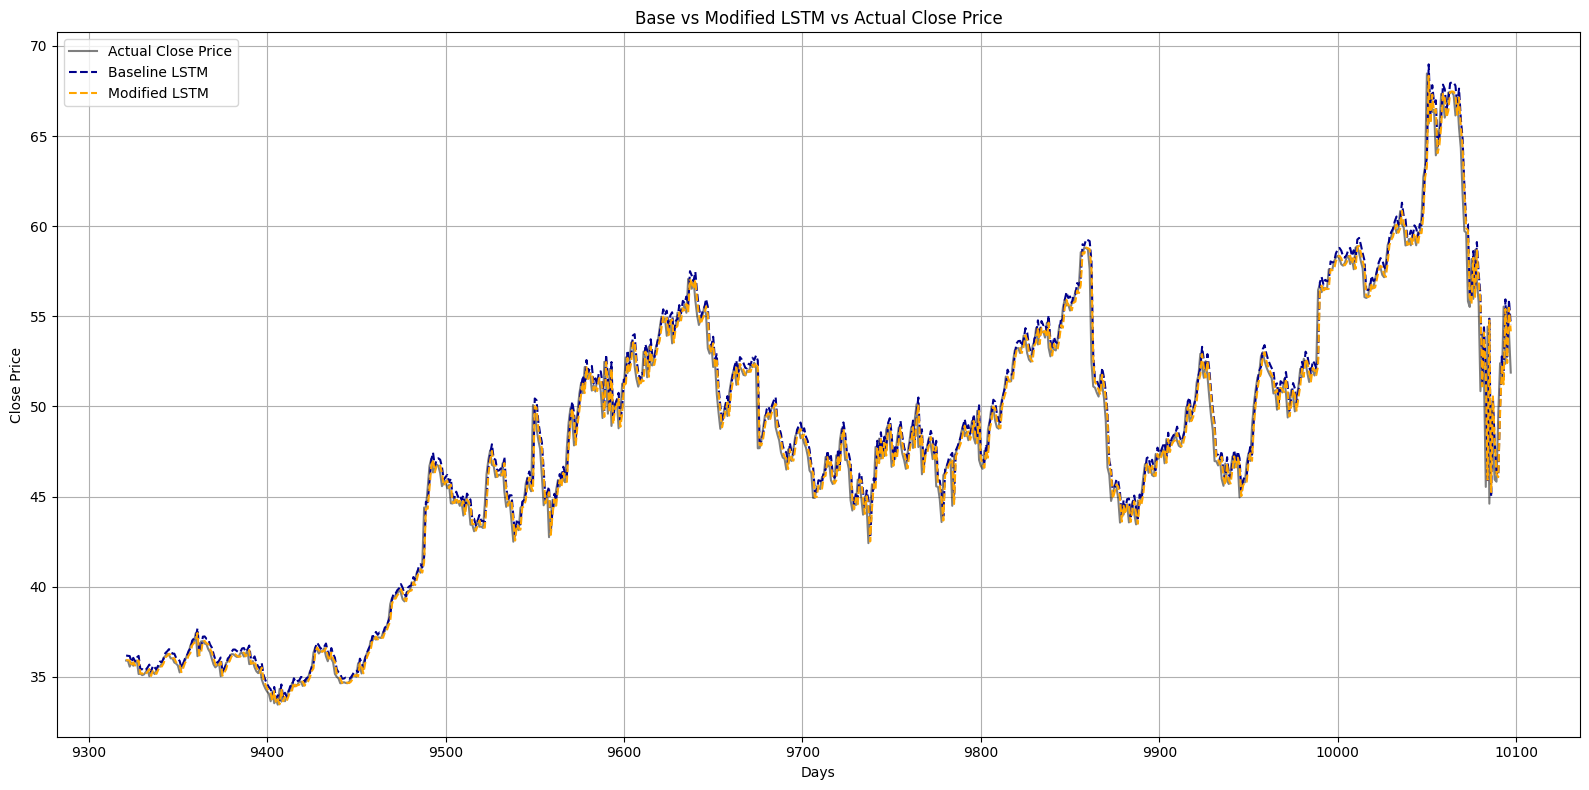

In [35]:
plt.figure(figsize=(16, 8))

plt.plot(df_result.index, y_true, label='Actual Close Price', color='black', alpha=0.5)
plt.plot(df_result.index, df_result['pred'], label='Baseline LSTM', color='darkblue', linestyle='--')
plt.plot(df_result2.index, df_result2['pred'], label='Modified LSTM', color='orange', linestyle='--')

plt.title('Base vs Modified LSTM vs Actual Close Price')
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()